# Final Submission Report: Engagement and Capital Efficiency

**CIS 509: Analytics for Unstructured Data · Team 4**  
**John Wheeler, Ryan Wolff, Cameron Anthony · September 2026**

**Question.** Can outcomes from comparable public investments support a trained estimate of Yelp engagement per million dollars for a proposed project? The map displays sentiment; this report studies engagement as review activity. These are distinct outcomes.

**Result.** We fit a supervised regression on other projects' pre-opening conditions and observed outcomes, then test every project as an unseen case. It is a research prototype. Its held-out errors and the small project sample do not support selecting a public budget or location. We also train course-style TF–IDF text classifiers as a separate sentiment check.

## 1. Reproducibility and course concepts

This notebook uses supervised learning, train/test separation, TF–IDF, Naive Bayes, linear SVM, and regression from Weeks 2–3 and Lab 2. The independent unit for CE is a *project*, so randomly splitting businesses would leak an investment into both training and testing. The text experiment holds out whole businesses.

The project table in `data/derived/ce_project_training.csv` can be regenerated by `src/build_ce_training_data.py` from the Yelp archive, five mapped footprints, six center proxies, and the retained **717-listing full Sun Link route inventory**. `src/sample_review_text.py` generates a local, Git-ignored text sample. Both regeneration steps require the original Yelp archive. Run this notebook from the repository root.

In [1]:
from pathlib import Path
import gzip, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, GroupShuffleSplit, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score, confusion_matrix

root = Path.cwd()
while not (root / 'src/train_ce_model.py').exists() and root != root.parent:
    root = root.parent
assert (root / 'src/train_ce_model.py').exists(), 'Run from the project repository.'
sys.path.insert(0, str(root / 'src'))
plt.rcParams.update({'figure.figsize': (9, 5), 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository:', root)

Repository: /Users/johnwheeler/Documents/AIB/CIS-509-Analytics-Unstructured-Data/neighborhood-sentiment-map


## 2. Outcome definition and data audit

Each row uses two pre-opening and two post-opening calendar years; the opening year is omitted. The near area is within 500 m of the mapped project or proxy center; the comparison band is 1.5–8 km away. **CE = (near post reviews − near pre reviews × comparison post/pre growth factor) ÷ reported project cost in $ millions.** All nearby Yelp listings count, including those without pre-opening reviews. CE is an observational activity proxy, not a financial return or causal effect.

Five original projects have mapped footprints. Six newer examples have center-point approximations, which under-cover long trails. The local metre approximation changes original footprint counts by a few listings; Sun Link uses the exact retained full-route cohort. Cost reporting varies in public/private scope.

In [2]:
d = pd.read_csv(root / 'data/derived/ce_project_training.csv')
assert len(d) == 11 and d.project.is_unique
sun = d.set_index('project').loc['Sun Link']
assert int(sun.near_listings) == 717 and int(sun.far_listings) == 4151
assert np.isclose(sun.ce_reviews_per_million, -11.233294003911482)
recomputed = (d.near_post_reviews - d.near_pre_reviews *
              d.far_post_reviews / d.far_pre_reviews) / d.cost_millions
assert np.allclose(d.ce_reviews_per_million, recomputed)
print(f'{len(d)} projects in {d.city.nunique()} cities; {sum(d.geometry_quality == "mapped_footprint")} mapped footprints; {sum(d.geometry_quality == "center_proxy")} center proxies.')
display(d[['project','city','geometry_quality','cost_millions','near_listings',
           'near_baseline_reviewed','ce_reviews_per_million']].round(2))

11 projects in 7 cities; 5 mapped footprints; 6 center proxies.


,project,city,geometry_quality,cost_millions,near_listings,near_baseline_reviewed,ce_reviews_per_million
0,Lafitte,New Orleans,mapped_footprint,9.1,433,242,163.41
1,Sun Link,Tucson,mapped_footprint,196.5,717,278,-11.23
2,Dilworth Park,Philadelphia,mapped_footprint,55.0,1696,855,70.69
3,Water Works Park,Tampa,mapped_footprint,7.4,75,6,131.72
4,Riverfront / Ascend,Nashville,mapped_footprint,52.0,308,123,124.08
5,Tampa Riverwalk,Tampa,center_proxy,32.0,225,98,6.11
6,Schuylkill Boardwalk,Philadelphia,center_proxy,18.0,143,81,-41.37
7,The Rail Park,Philadelphia,center_proxy,10.3,291,173,114.60
8,Crescent Park,New Orleans,center_proxy,31.2,57,28,-1.39
9,Indianapolis Cultural Trail,Indianapolis,center_proxy,63.0,456,176,-18.78


In [3]:
audit = pd.DataFrame({
    'measure': ['Project outcomes','Nearby Yelp listings','Pre-opening reviewed listings','Cost ($M)','Observed CE (reviews/$M)'],
    'min': [len(d),d.near_listings.min(),d.near_baseline_reviewed.min(),d.cost_millions.min(),d.ce_reviews_per_million.min()],
    'median': [len(d),d.near_listings.median(),d.near_baseline_reviewed.median(),d.cost_millions.median(),d.ce_reviews_per_million.median()],
    'max': [len(d),d.near_listings.max(),d.near_baseline_reviewed.max(),d.cost_millions.max(),d.ce_reviews_per_million.max()],
})
display(audit.round(2))
print('Missing project-table cells:', int(d.isna().sum().sum()))
display(d.project_type.value_counts().rename_axis('project type').to_frame('projects'))

,measure,min,median,max
0,Project outcomes,11.00,11.00,11.00
1,Nearby Yelp listings,43.00,291.00,1696.00
2,Pre-opening reviewed listings,6.00,123.00,855.00
3,Cost ($M),7.40,32.00,380.00
4,Observed CE (reviews/$M),-41.37,6.11,163.41


Missing project-table cells: 0


,projects
project type,
Greenway / public space,1
Streetcar / transit,1
Civic plaza / transit access,1
Riverfront park / spring restoration,1
Riverfront park / performance venue,1
Waterfront trail / linear promenade,1
Over-water boardwalk / linear trail,1
Elevated viaduct linear greenway,1
Linear riverfront park,1


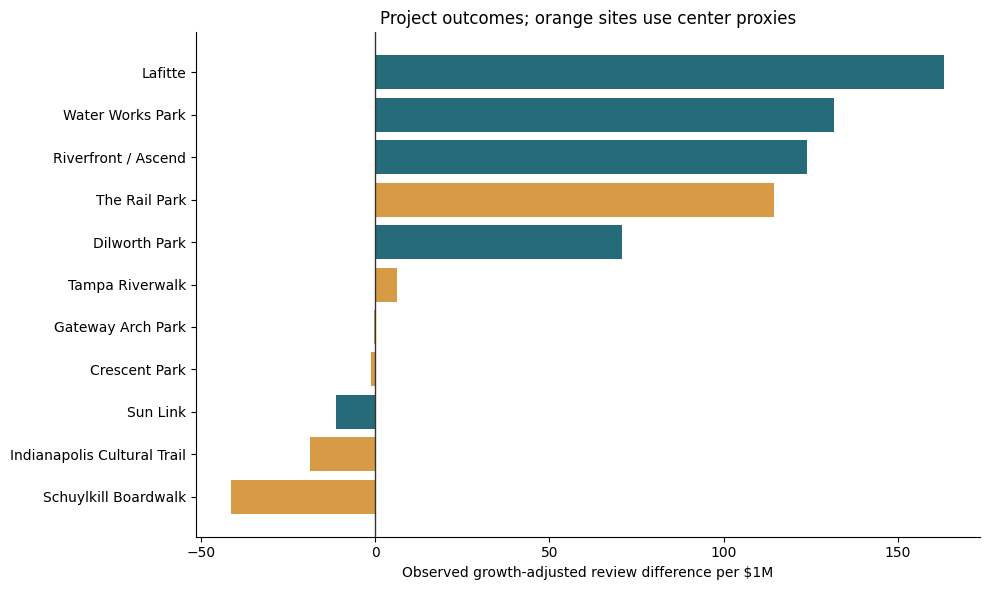

,project,near_growth_pct,comparison_growth_pct
0,Lafitte,146.5,104.6
1,Sun Link,187.4,245.4
2,Dilworth Park,112.3,89.8
3,Water Works Park,2368.8,338.1
4,Riverfront / Ascend,443.9,179.6
5,Tampa Riverwalk,206.4,193.5
6,Schuylkill Boardwalk,15.7,65.0
7,The Rail Park,-4.4,-23.6
8,Crescent Park,155.4,162.6
9,Indianapolis Cultural Trail,232.7,286.5


In [4]:
s = d.sort_values('ce_reviews_per_million')
colors = np.where(s.geometry_quality.eq('mapped_footprint'),'#256b79','#d79a45')
fig,ax = plt.subplots(figsize=(10,6))
ax.barh(s.project,s.ce_reviews_per_million,color=colors)
ax.axvline(0,color='#333',lw=1)
ax.set(xlabel='Observed growth-adjusted review difference per $1M',title='Project outcomes; orange sites use center proxies')
plt.tight_layout();plt.show()
display(d.assign(near_growth_pct=100*(d.near_post_reviews/d.near_pre_reviews-1),
                 comparison_growth_pct=100*(d.far_post_reviews/d.far_pre_reviews-1))
        [['project','near_growth_pct','comparison_growth_pct']].round(1))

**Suitability rule.** Water Works Park has only six nearby businesses with pre-opening reviews. Its CE is described but withheld from training. The remaining ten are independent *projects*, not thousands of independent training examples. We therefore use regularized linear regression and a mean-only baseline. A neural network or transformer for CE would have far more degrees of freedom than this evidence can validate. Center proxies and common metro trends weaken transferability.

## 3. Train and test the CE outcome model

The target is **growth-adjusted excess reviews per $1M (CE)**. Inputs known before opening are pre-opening reviews per previously reviewed business, proposed cost, and the count of nearby businesses with pre-opening reviews. Each gets log(1+x), is standardized inside each training fold, and enters ridge regression (α = 10). The outcome uses all nearby Yelp listings, but the prediction features never use businesses first observed after opening. Comparison *post* activity constructs historical labels but never enters prediction features.

We leave one investment out, refit on all others, and compare with the observed CE. A mean-only baseline uses the same folds. Model form and α are fixed; uncertainty remains high with ten cases.

In [5]:
eligible = d.loc[(d.near_baseline_reviewed>=20)&(d.near_pre_reviews>0)&
                 (d.far_pre_reviews>0)&(d.cost_millions>0)].copy().reset_index(drop=True)
X = pd.DataFrame({
    'log_pre_reviews_per_active_business':np.log1p(eligible.near_pre_reviews/eligible.near_baseline_reviewed),
    'log_cost_millions':np.log1p(eligible.cost_millions),
    'log_baseline_reviewed':np.log1p(eligible.near_baseline_reviewed),
})
y = eligible.ce_reviews_per_million.to_numpy()
baseline_pred = cross_val_predict(DummyRegressor(strategy='mean'),X,y,cv=LeaveOneOut())
ridge = make_pipeline(StandardScaler(),Ridge(alpha=10.0))
model_pred = cross_val_predict(ridge,X,y,cv=LeaveOneOut())
ridge.fit(X,y)
heldout = eligible[['project','city','geometry_quality','ce_reviews_per_million']].copy()
heldout['ridge_ce'] = model_pred
heldout['mean_baseline_ce'] = baseline_pred
heldout['absolute_error'] = (heldout.ce_reviews_per_million-heldout.ridge_ce).abs()
display(heldout.round(2))

,project,city,geometry_quality,ce_reviews_per_million,ridge_ce,mean_baseline_ce,absolute_error
0,Lafitte,New Orleans,mapped_footprint,163.41,24.99,26.92,138.43
1,Sun Link,Tucson,mapped_footprint,-11.23,32.02,46.32,43.26
2,Dilworth Park,Philadelphia,mapped_footprint,70.69,74.60,37.22,3.91
3,Riverfront / Ascend,Nashville,mapped_footprint,124.08,30.17,31.29,93.91
4,Tampa Riverwalk,Tampa,center_proxy,6.11,38.28,44.40,32.17
5,Schuylkill Boardwalk,Philadelphia,center_proxy,-41.37,59.78,49.67,101.14
6,The Rail Park,Philadelphia,center_proxy,114.60,71.85,32.34,42.75
7,Crescent Park,New Orleans,center_proxy,-1.39,35.41,45.23,36.80
8,Indianapolis Cultural Trail,Indianapolis,center_proxy,-18.78,36.63,47.16,55.41
9,Gateway Arch Park,Saint Louis,center_proxy,-0.44,-15.72,45.12,15.28


,model,MAE CE reviews/$M,Correct CE direction
0,Mean-only baseline,69.00,0.5
1,"Ridge, 3 pre-opening/proposal inputs",56.31,0.6


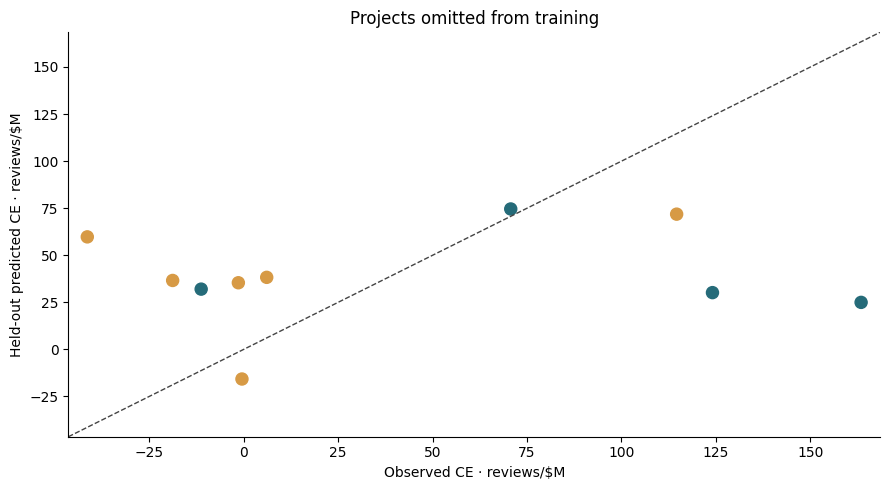

In [6]:
results = pd.DataFrame([
    {'model':'Mean-only baseline',
     'MAE CE reviews/$M':mean_absolute_error(eligible.ce_reviews_per_million,baseline_pred),
     'Correct CE direction':np.mean(np.sign(y)==np.sign(baseline_pred))},
    {'model':'Ridge, 3 pre-opening/proposal inputs',
     'MAE CE reviews/$M':mean_absolute_error(eligible.ce_reviews_per_million,model_pred),
     'Correct CE direction':np.mean(np.sign(y)==np.sign(model_pred))},
])
display(results.round(2))
fig,ax = plt.subplots()
ax.scatter(heldout.ce_reviews_per_million,heldout.ridge_ce,
           c=np.where(heldout.geometry_quality.eq('mapped_footprint'),'#256b79','#d79a45'),s=75)
lo=min(heldout.ce_reviews_per_million.min(),heldout.ridge_ce.min())-5
hi=max(heldout.ce_reviews_per_million.max(),heldout.ridge_ce.max())+5
ax.plot([lo,hi],[lo,hi],color='#444',ls='--',lw=1)
ax.set(xlim=(lo,hi),ylim=(lo,hi),xlabel='Observed CE · reviews/$M',ylabel='Held-out predicted CE · reviews/$M',title='Projects omitted from training')
plt.tight_layout();plt.show()

In [7]:
artifact=json.loads((root/'data/derived/ce_trained_model.json').read_text())
assert artifact['metrics']['n_projects_trained']==len(eligible)
assert np.isclose(artifact['metrics']['mae_ce_reviews_per_million'],results.iloc[1]['MAE CE reviews/$M'])
assert np.allclose(artifact['coefficients'],ridge[-1].coef_)
print('Saved model:',artifact['version'])
print('Held-out CE MAE:',round(artifact['metrics']['mae_ce_reviews_per_million'],2))
print('Correct CE direction:',f"{artifact['metrics']['sign_accuracy']:.0%}")

Saved model: ce-project-ridge-v2
Held-out CE MAE: 56.31
Correct CE direction: 60%


**Interpretation.** This is a fitted model of ten observed outcomes. Its leave-one-project-out CE mean absolute error is about 56 reviews/$1M, versus about 69 for the mean-only baseline. It gets the direction right for six of ten projects. That is too weak to rank locations or optimize a public budget. Its cost coefficient cannot be interpreted as the effect of adding funding: cost, project scale, geography, and type are entangled. The app exposes the result as an *experimental learned estimate* with held-out error visible.

Full alignments are needed for the six center proxies. An eight-mile trail cannot be represented by a 500 m circle at one point. Verified public-cost ledgers and more independent outcomes are also needed.

## 4. Course text-analytics check

The map's sentiment layer is separate from CE. We train TF–IDF (up to 1,000 terms and bigrams), Multinomial Naive Bayes, and linear SVM. Stars 1–2 provide weak negative labels; 4–5 weak positive labels; 3-star reviews are omitted. The split holds out whole businesses. Agreement with Yelp stars is not sentiment specifically about a public investment.

In [8]:
from sample_review_text import build as build_text_sample
with gzip.open(build_text_sample(),'rt',encoding='utf-8') as f:
    reviews=pd.DataFrame(json.load(f))
reviews['positive']=(reviews.stars>=4).astype(int)
reviews['words']=reviews.text.str.split().str.len()
display(pd.DataFrame({'reviews':[len(reviews)],'unique_businesses':[reviews.business_id.nunique()],
                      'negative_share':[1-reviews.positive.mean()],
                      'median_words':[reviews.words.median()],
                      'vocabulary_size':[len(set(' '.join(reviews.text.str.lower()).split()))]}).round(2))
display(reviews.groupby('metro').agg(reviews=('text','size'),median_words=('words','median'),positive_share=('positive','mean')).round(2))

,reviews,unique_businesses,negative_share,median_words,vocabulary_size
0,5000,3763,0.24,75.0,37012


,reviews,median_words,positive_share
metro,,,
Nashville,1000,75.0,0.78
NewOrleans,1000,72.0,0.81
Philadelphia,1000,82.0,0.77
TampaBay,1000,72.0,0.75
Tucson,1000,74.0,0.71


In [9]:
train_idx,test_idx=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=509)
                        .split(reviews,reviews.positive,groups=reviews.business_id))
assert set(reviews.business_id.iloc[train_idx]).isdisjoint(set(reviews.business_id.iloc[test_idx]))
text_models={
    'TF–IDF + Multinomial NB':make_pipeline(TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=3,stop_words='english'),MultinomialNB()),
    'TF–IDF + linear SVM':make_pipeline(TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=3,stop_words='english'),LinearSVC(dual=True,random_state=509)),
}
scores=[]
truth=reviews.positive.iloc[test_idx]
for name in ['Majority baseline',*text_models]:
    if name=='Majority baseline':
        predicted=np.ones(len(test_idx),dtype=int)
    else:
        model=text_models[name]
        model.fit(reviews.text.iloc[train_idx],reviews.positive.iloc[train_idx])
        predicted=model.predict(reviews.text.iloc[test_idx])
    scores.append({'model':name,'accuracy':accuracy_score(truth,predicted),
                   'macro_F1':f1_score(truth,predicted,average='macro'),
                   'negative_F1':f1_score(truth,predicted,pos_label=0)})
display(pd.DataFrame(scores).round(3))
svm_pred=text_models['TF–IDF + linear SVM'].predict(reviews.text.iloc[test_idx])
display(pd.DataFrame(confusion_matrix(truth,svm_pred),index=['actual negative','actual positive'],
                     columns=['predicted negative','predicted positive']))

,model,accuracy,macro_F1,negative_F1
0,Majority baseline,0.769,0.435,0.000
1,TF–IDF + Multinomial NB,0.888,0.822,0.712
2,TF–IDF + linear SVM,0.915,0.878,0.811


,predicted negative,predicted positive
actual negative,184,50
actual positive,36,741


The classifier tests a course method on unstructured reviews. It does **not** enter CE: post-opening language would leak information unavailable for a proposed project. Weak star labels and Yelp's reviewer/business selection also limit claims about neighborhood sentiment.

## 5. Final solution and next evidence

The map displays observed sentiment and time-varying engagement. The studio keeps transparent observed-reference arithmetic and adds the trained CE prototype with its held-out error. A negative CE means nearby review growth lagged the comparison area; it does not mean a project failed on all civic outcomes.

Before recommending a budget or site: map full project alignments, verify public-only costs and opening dates, add many independent projects across types and cities, collect visits or transaction outcomes, and repeat project-held-out evaluation. Only then compare richer models, possibly with embeddings from **pre-opening** review text.

**Generative AI disclosure.** OpenAI Codex assisted with code, audit design, debugging, visuals, and drafting. The team remains responsible for verifying sources, calculations, and interpretation before submission.